# Vorlage Plausi-Tests

### Kurzbeschreibung
Wochenaufenthalter/-innen in der Stadt Zürich, nach Altersklasse, Herkunft, Stadtquartier, Stadtkreis, Zuzugskanton und Zuzugsbezirk, seit 1993

Datum: 24.02.2025


Dataset auf PROD-Datakatalog: Link 

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alter_herkunft_od4117


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [1]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [2]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [3]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [4]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [5]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
#pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [6]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [7]:
package_name = "bev_fertilitaet_jahr_alter_herkunft_od4117"

In [8]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV411OD4117"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alter_herkunft_od4117/download/BEV411OD4117.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alter_herkunft_od4117 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_alter_herkunft_od4117 

data_source: web


In [9]:
data2betested.head(2).T

,0,1
ThemaCd,1,1
ThemaLang,"Fertilität nach Jahr, Alter und Herkunft der M...","Fertilität nach Jahr, Alter und Herkunft der M..."
StichtagDatJahr,2023-01-01 00:00:00,2023-01-01 00:00:00
HerkunftMutterCd,1,1
HerkunftMutterLang,Schweizerinnen,Schweizerinnen
AlterVMutterKlasseCd,1,2
AlterVMutterKlasseLang,15 bis 24,25 bis 29
AnzGebuWir,76,226
Frauen15bis49_noDM,15580.0,12411.0
Fertilitaetsrate_noDM,4.9,18.2


Berechne weitere Attribute falls notwendig

In [10]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

ThemaCd                            int64
ThemaLang                         object
StichtagDatJahr           datetime64[ns]
HerkunftMutterCd                   int64
HerkunftMutterLang                object
AlterVMutterKlasseCd               int64
AlterVMutterKlasseLang            object
AnzGebuWir                         int64
Frauen15bis49_noDM               float64
Fertilitaetsrate_noDM            float64
StichtagDatJahr_str               object
Jahr                      datetime64[ns]
Jahr_end                  datetime64[ns]
Jahr_nbr                           int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [11]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1894 und ein Maximumjahr von 2023


In [12]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1894-12-31 und ein Maximumjahr von 2023-12-31


### Einfache Datentests

In [13]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1383 entries, 0 to 1382
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ThemaCd                 1383 non-null   int64         
 1   ThemaLang               1383 non-null   object        
 2   StichtagDatJahr         1383 non-null   datetime64[ns]
 3   HerkunftMutterCd        1383 non-null   int64         
 4   HerkunftMutterLang      1383 non-null   object        
 5   AlterVMutterKlasseCd    1383 non-null   int64         
 6   AlterVMutterKlasseLang  1383 non-null   object        
 7   AnzGebuWir              1383 non-null   int64         
 8   Frauen15bis49_noDM      1220 non-null   float64       
 9   Fertilitaetsrate_noDM   1220 non-null   float64       
 10  StichtagDatJahr_str     1383 non-null   object        
 11  Jahr                    1383 non-null   datetime64[ns]
 12  Jahr_end                1383 non-null   datetime64[ns

In [14]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 1,383 rows (observations) and 14 columns (variables).
There seem to be 3 exact duplicates in the data.


Beschreibe einzelne Attribute

In [15]:
data2betested.describe()

,ThemaCd,StichtagDatJahr,HerkunftMutterCd,AlterVMutterKlasseCd,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,Jahr,Jahr_end,Jahr_nbr
count,1383.000000,1383,1383.000000,1383.000000,1383.000000,1220.000000,1220.000000,1383,1383,1383.000000
mean,1.903109,1978-04-11 19:05:20.173535776,0.997831,2.147505,1172.358641,24301.743443,46.797213,1978-04-11 19:05:20.173535776,1979-04-11 00:53:06.117136640,1978.276211
min,1.000000,1894-01-01 00:00:00,0.000000,0.000000,4.000000,1071.000000,0.600000,1894-01-01 00:00:00,1894-12-31 00:00:00,1894.000000
25%,1.000000,1966-01-01 00:00:00,0.000000,0.000000,258.000000,8585.500000,22.350000,1966-01-01 00:00:00,1966-12-31 00:00:00,1966.000000
50%,2.000000,1985-01-01 00:00:00,1.000000,2.000000,622.000000,14336.000000,42.500000,1985-01-01 00:00:00,1985-12-31 00:00:00,1985.000000
75%,3.000000,2004-01-01 00:00:00,2.000000,4.000000,1614.500000,23897.500000,69.200000,2004-01-01 00:00:00,2004-12-31 00:00:00,2004.000000
max,4.000000,2023-01-01 00:00:00,2.000000,5.000000,6147.000000,121810.000000,195.000000,2023-01-01 00:00:00,2023-12-31 00:00:00,2023.000000
std,1.020420,NaN,0.817232,1.806867,1376.486743,28274.438362,32.131668,NaN,NaN,33.696488


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [16]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [17]:
data2betested.index.year.unique()

Index([1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903,
       ...
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
      dtype='int32', name='StichtagDatJahr', length=130)

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [18]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,ThemaLang,HerkunftMutterLang,AlterVMutterKlasseLang,StichtagDatJahr_str,Jahr,Jahr_end
count,1383,1383,1383,1383,1383,1383
unique,4,3,6,130,NaN,NaN
top,"Fertilität nach Jahr, Alter und Herkunft der M...",ohne Herkunft,ohne Altersklasse,1941-01-01,NaN,NaN
freq,660,463,393,19,NaN,NaN
mean,NaN,NaN,NaN,NaN,1978-04-11 19:05:20.173535840,1979-04-11 00:53:06.117136640
min,NaN,NaN,NaN,NaN,1894-01-01 00:00:00,1894-12-31 00:00:00
25%,NaN,NaN,NaN,NaN,1966-01-01 00:00:00,1966-12-31 00:00:00
50%,NaN,NaN,NaN,NaN,1985-01-01 00:00:00,1985-12-31 00:00:00
75%,NaN,NaN,NaN,NaN,2004-01-01 00:00:00,2004-12-31 00:00:00
max,NaN,NaN,NaN,NaN,2023-01-01 00:00:00,2023-12-31 00:00:00


Beschreibe numerische Attribute

In [19]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,ThemaCd,HerkunftMutterCd,AlterVMutterKlasseCd,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,Jahr_nbr
count,"1,383","1,383","1,383","1,383","1,220","1,220","1,383"
mean,2,1,2,"1,172","24,302",47,"1,978"
std,1,1,2,"1,376","28,274",32,34
min,1,0,0,4,"1,071",1,"1,894"
25%,1,0,0,258,"8,586",22,"1,966"
50%,2,1,2,622,"14,336",42,"1,985"
75%,3,2,4,"1,614","23,898",69,"2,004"
max,4,2,5,"6,147","121,810",195,"2,023"


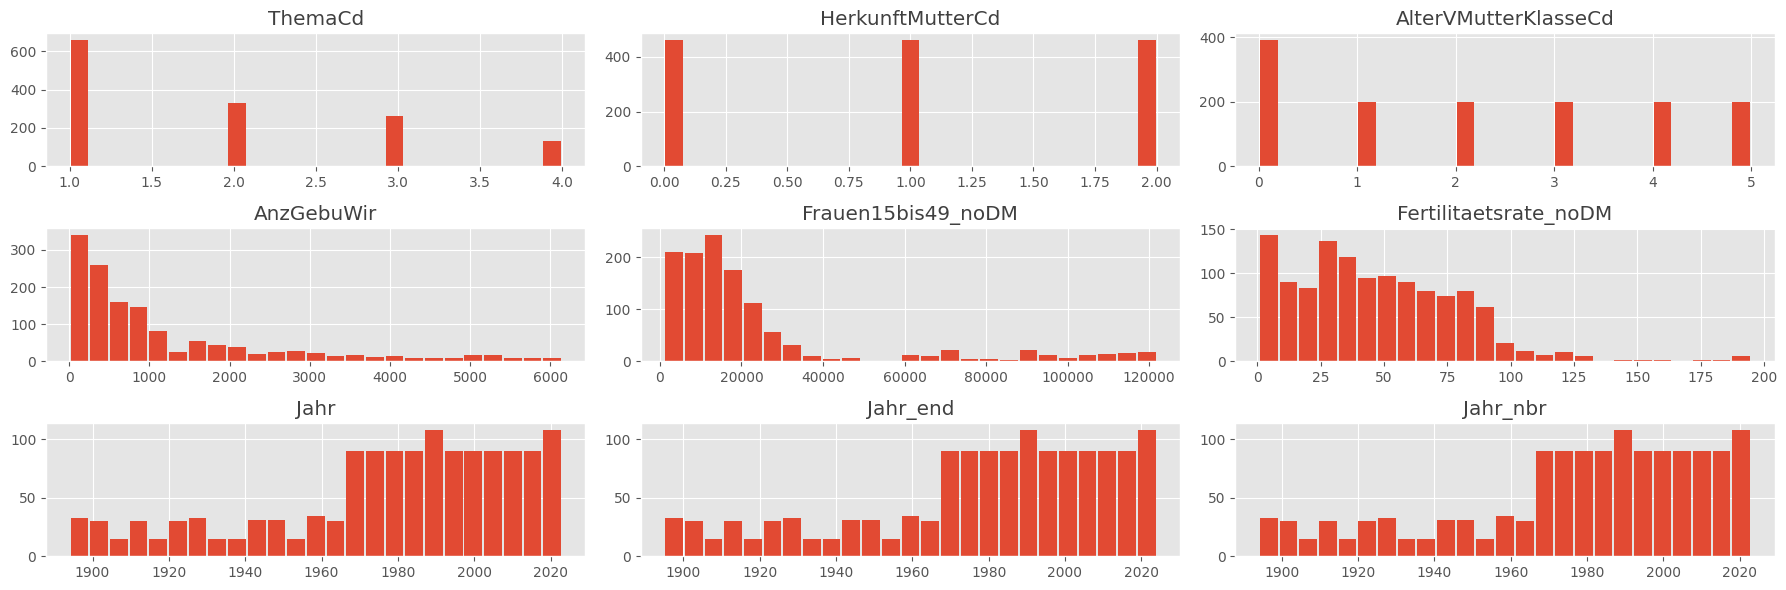

In [20]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [ ]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated(keep=False)]
duplicate_rows

,StichtagDatJahr,ThemaCd,ThemaLang,HerkunftMutterCd,HerkunftMutterLang,AlterVMutterKlasseCd,AlterVMutterKlasseLang,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1941-01-01,4,Fertilität nach Jahr,0,ohne Herkunft,0,ohne Altersklasse,4926,109470.0,45.0,1941-01-01,1941-01-01,1941-12-31,1941
1,1941-01-01,4,Fertilität nach Jahr,0,ohne Herkunft,0,ohne Altersklasse,4926,109470.0,45.0,1941-01-01,1941-01-01,1941-12-31,1941
2,1950-01-01,4,Fertilität nach Jahr,0,ohne Herkunft,0,ohne Altersklasse,5432,116075.0,46.8,1950-01-01,1950-01-01,1950-12-31,1950
3,1950-01-01,4,Fertilität nach Jahr,0,ohne Herkunft,0,ohne Altersklasse,5432,116075.0,46.8,1950-01-01,1950-01-01,1950-12-31,1950
4,1960-01-01,4,Fertilität nach Jahr,0,ohne Herkunft,0,ohne Altersklasse,6084,118029.0,51.5,1960-01-01,1960-01-01,1960-12-31,1960
5,1960-01-01,4,Fertilität nach Jahr,0,ohne Herkunft,0,ohne Altersklasse,6084,118029.0,51.5,1960-01-01,1960-01-01,1960-12-31,1960


### Nullwerte und Missings?

In [22]:
data2betested.isnull().sum()

ThemaCd                     0
ThemaLang                   0
HerkunftMutterCd            0
HerkunftMutterLang          0
AlterVMutterKlasseCd        0
AlterVMutterKlasseLang      0
AnzGebuWir                  0
Frauen15bis49_noDM        163
Fertilitaetsrate_noDM     163
StichtagDatJahr_str         0
Jahr                        0
Jahr_end                    0
Jahr_nbr                    0
dtype: int64

In den Metadaten beschrieben:
> "Bei den Geburtenzahlen der Jahr 1894, 1900 und 1910 nach Alter der Mutter waren bloss Mittelwerte über mehrere Jahre verfügbar (1894: Mittelwert der Geburten 1893 bis 1895; 1900: Mittelwert der Geburten 1899 bis 1902; 1910: Mittelwert der Geburten 1909 bis 1912). Quelle: Statistisches Jahrbuch der Stadt Zürich, Jahre 1912 und 1913. Die Geburtenzahlen dieser Jahre nach Alter der Mutter wurden auf ganze Zahlen gerunden; die Fertilitätsrate wurde jedoch noch vor dem Runden berechnet."

In [63]:
data2betested[data2betested['Fertilitaetsrate_noDM'].isna()].reset_index() \
    .groupby(['StichtagDatJahr','ThemaLang']) \
    .agg(
        sum_AnzGebuWir = ('AnzGebuWir', 'sum'),
        count = ('AnzGebuWir', 'count')
    ).unstack()

sum_AnzGebuWir                                               \
ThemaLang       Fertilität nach Jahr Fertilität nach Jahr und Herkunft der Mutter   
StichtagDatJahr                                                                     
1895-01-01                    3800.0                                       3800.0   
1896-01-01                    4458.0                                       4458.0   
1897-01-01                    4613.0                                       4613.0   
1898-01-01                    4834.0                                       4834.0   
1899-01-01                    5084.0                                       5084.0   
...                              ...                                          ...   
1961-01-01                       NaN                                       6147.0   
1962-01-01                       NaN                                       6034.0   
1963-01-01                       NaN                                       6002.0   
1964-01-01                       NaN                                       5746.0   
1965-01-01                       NaN                                       5582.0   

                               count                                               
ThemaLang       Fertilität nach Jahr Fertilität nach Jahr und Herkunft der Mutter  
StichtagDatJahr                                                                    
1895-01-01                       1.0                                          2.0  
1896-01-01                       1.0                                          2.0  
1897-01-01                       1.0                                          2.0  
1898-01-01                       1.0                                          2.0  
1899-01-01                       1.0                                          2.0  
...                              ...                                          ...  
1961-01-01                       NaN                                          2.0  
1962-01-01                       NaN                                          2.0  
1963-01-01                       NaN                                          2.0  
1964-01-01                       NaN                                          2.0  
1965-01-01                       NaN                                          2.0  

[64 rows x 4 columns]

In [23]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

Anmerkung Alex: Scheinbar kann man die Daten nicht Gruppieren (es geht um die Fertilitätsrate). Der Schlüssel ist wohl die Spalte Thema. Je nach Thema gibt es verschiedene Untergruppierungen, die dazu kommen (Jahr, Herkunft, Alter).

In [30]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(10)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,2023-01-01,2023,2023-12-31,17900,487240.0,38.916667
1,2022-01-01,2022,2022-12-31,18152,482428.0,39.755556
2,2021-01-01,2021,2021-12-31,21044,472816.0,46.994444
3,2020-01-01,2020,2020-12-31,20532,470896.0,45.950000
4,2019-01-01,2019,2019-12-31,20536,470916.0,45.933333
5,2018-01-01,2018,2018-12-31,20848,464116.0,47.661111
6,2017-01-01,2017,2017-12-31,20960,458304.0,48.688889
7,2016-01-01,2016,2016-12-31,20704,450080.0,48.833333
8,2015-01-01,2015,2015-12-31,20764,444752.0,49.988889
9,2014-01-01,2014,2014-12-31,20580,439500.0,50.255556


In [32]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftMutterCd', 'HerkunftMutterLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('HerkunftMutterCd', ascending=False) 
agg_herk.reset_index().head(10)

,HerkunftMutterCd,HerkunftMutterLang,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,2,Ausländerinnen,260359,3647652.0,55.983590
1,1,Schweizerinnen,534972,9286894.0,38.177949
2,0,ohne Herkunft,811772,16567793.0,43.560427


In [34]:
agg_thema = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['ThemaCd', 'ThemaLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('ThemaCd', ascending=False) 
agg_thema.reset_index().head(10)

,ThemaCd,ThemaLang,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,4,Fertilität nach Jahr,555192,10100520.0,42.306186
1,3,Fertilität nach Jahr und Herkunft der Mutter,538750,6467273.0,44.921538
2,2,Fertilität nach Jahr und Alter der Mutter,256580,6467273.0,43.934769
3,1,"Fertilität nach Jahr, Alter und Herkunft der M...",256581,6467273.0,47.512615


In [35]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterVMutterKlasseCd', 'AlterVMutterKlasseLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('AlterVMutterKlasseCd', ascending=True) 
agg_age.reset_index().head(11)

,AlterVMutterKlasseCd,AlterVMutterKlasseLang,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,0,ohne Altersklasse,1093942,16567793.0,43.803965
1,1,15 bis 24,90656,3072400.0,34.733846
2,2,25 bis 29,143864,2288446.0,69.054359
3,3,30 bis 34,161182,2196074.0,73.543077
4,4,35 bis 39,95712,1944760.0,47.443077
5,5,40 bis 49,21747,3432866.0,6.825641


In [36]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'ThemaCd', 'ThemaLang', 'HerkunftMutterCd', 'HerkunftMutterLang',
       'AlterVMutterKlasseCd', 'AlterVMutterKlasseLang', 'AnzGebuWir', 'Frauen15bis49_noDM',
       'Fertilitaetsrate_noDM', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

#### Entwicklung Fertilitätsrate: Thema 4 Fertilität nach Jahr

In [34]:
data2betested[['ThemaCd','ThemaLang']].reset_index(drop=True).drop_duplicates()

,ThemaCd,ThemaLang
0,4,Fertilität nach Jahr
1,1,"Fertilität nach Jahr, Alter und Herkunft der M..."
2,3,Fertilität nach Jahr und Herkunft der Mutter
12,2,Fertilität nach Jahr und Alter der Mutter


In [35]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data2betested['ThemaCd']==4]

myAgg1.reset_index().head(3)

,StichtagDatJahr,ThemaCd,ThemaLang,HerkunftMutterCd,HerkunftMutterLang,AlterVMutterKlasseCd,AlterVMutterKlasseLang,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1894-01-01,4,Fertilität nach Jahr,0,ohne Herkunft,0,ohne Altersklasse,3578,36447.0,98.2,1894-01-01,1894-01-01,1894-12-31,1894
1,1895-01-01,4,Fertilität nach Jahr,0,ohne Herkunft,0,ohne Altersklasse,3800,NaN,NaN,1895-01-01,1895-01-01,1895-12-31,1895
2,1896-01-01,4,Fertilität nach Jahr,0,ohne Herkunft,0,ohne Altersklasse,4458,NaN,NaN,1896-01-01,1896-01-01,1896-12-31,1896


In [37]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'Fertilitaetsrate_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    ,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilitätsrate nach Jahr, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

In [40]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'AnzGebuWir'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anzahl Geburten'
    ,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anzahl Geburten nach Jahr, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

In [41]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'Frauen15bis49_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anzahl Frauen im gebährfähigen Alter'
    ,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Frauen im gebährfähigen Alter nach Jahr, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 3 Fertilität nach Jahr und Herkunft der Mutter

In [38]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data2betested['ThemaCd']==3]

myAgg2.reset_index().head(3)

,StichtagDatJahr,ThemaCd,ThemaLang,HerkunftMutterCd,HerkunftMutterLang,AlterVMutterKlasseCd,AlterVMutterKlasseLang,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1894-01-01,3,Fertilität nach Jahr und Herkunft der Mutter,2,Ausländerinnen,0,ohne Altersklasse,1201,10211.0,117.6,1894-01-01,1894-01-01,1894-12-31,1894
1,1894-01-01,3,Fertilität nach Jahr und Herkunft der Mutter,1,Schweizerinnen,0,ohne Altersklasse,2377,26236.0,90.6,1894-01-01,1894-01-01,1894-12-31,1894
2,1895-01-01,3,Fertilität nach Jahr und Herkunft der Mutter,2,Ausländerinnen,0,ohne Altersklasse,1332,NaN,NaN,1895-01-01,1895-01-01,1895-12-31,1895


In [42]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'Fertilitaetsrate_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilitätsrate nach Jahr und Herkunft, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

In [43]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'AnzGebuWir'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Geburten'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anzahl Geburten nach Jahr und Herkunft, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

In [44]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'Frauen15bis49_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Frauen im gebährfähigen Alter'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anz. Frauen im gebährfähigen Alter nach Jahr und Herkunft, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 2 Fertilität nach Jahr und Alter der Mutter

In [51]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg3 = data2betested.loc[data2betested['ThemaCd']==2]

myAgg3.reset_index().head(3)

,StichtagDatJahr,ThemaCd,ThemaLang,HerkunftMutterCd,HerkunftMutterLang,AlterVMutterKlasseCd,AlterVMutterKlasseLang,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1894-01-01,2,Fertilität nach Jahr und Alter der Mutter,0,ohne Herkunft,1,15 bis 24,850,13242.0,64.2,1894-01-01,1894-01-01,1894-12-31,1894
1,1894-01-01,2,Fertilität nach Jahr und Alter der Mutter,0,ohne Herkunft,2,25 bis 29,1210,6407.0,188.8,1894-01-01,1894-01-01,1894-12-31,1894
2,1894-01-01,2,Fertilität nach Jahr und Alter der Mutter,0,ohne Herkunft,3,30 bis 34,884,5421.0,163.1,1894-01-01,1894-01-01,1894-12-31,1894


In [52]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg3.reset_index()
    ,x = 'StichtagDatJahr:T'
    ,y = 'Fertilitaetsrate_noDM:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    ,category = "AlterVMutterKlasseLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilität nach Jahr und Alter der Mutter, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 1 Fertilität nach Jahr, Alter und Herkunft der Mutter

#### Faced Grids

In [45]:
data2betested.columns

Index(['ThemaCd', 'ThemaLang', 'HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterKlasseCd',
       'AlterVMutterKlasseLang', 'AnzGebuWir', 'Frauen15bis49_noDM', 'Fertilitaetsrate_noDM',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [46]:
data2betested[['ThemaCd','ThemaLang']].reset_index(drop=True).drop_duplicates()

,ThemaCd,ThemaLang
0,4,Fertilität nach Jahr
1,1,"Fertilität nach Jahr, Alter und Herkunft der M..."
2,3,Fertilität nach Jahr und Herkunft der Mutter
12,2,Fertilität nach Jahr und Alter der Mutter


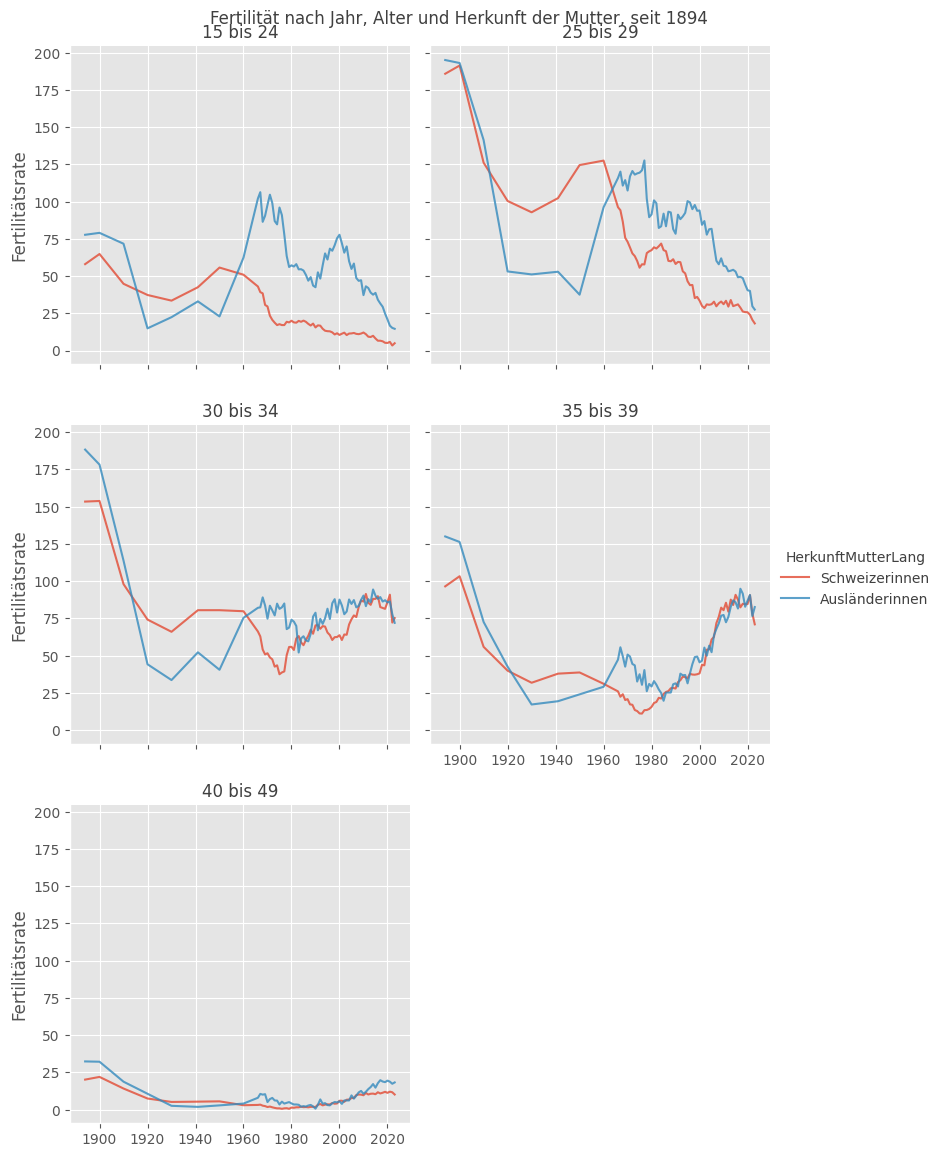

In [66]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested[data2betested['ThemaCd']==1].reset_index().sort_values('AlterVMutterKlasseLang')
    ,col = "AlterVMutterKlasseLang"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "Fertilitaetsrate_noDM"
    ,ylabel= "Fertilitätsrate"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Fertilität nach Jahr, Alter und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

In [56]:
data2betested.columns

Index(['ThemaCd', 'ThemaLang', 'HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterKlasseCd',
       'AlterVMutterKlasseLang', 'AnzGebuWir', 'Frauen15bis49_noDM', 'Fertilitaetsrate_noDM',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

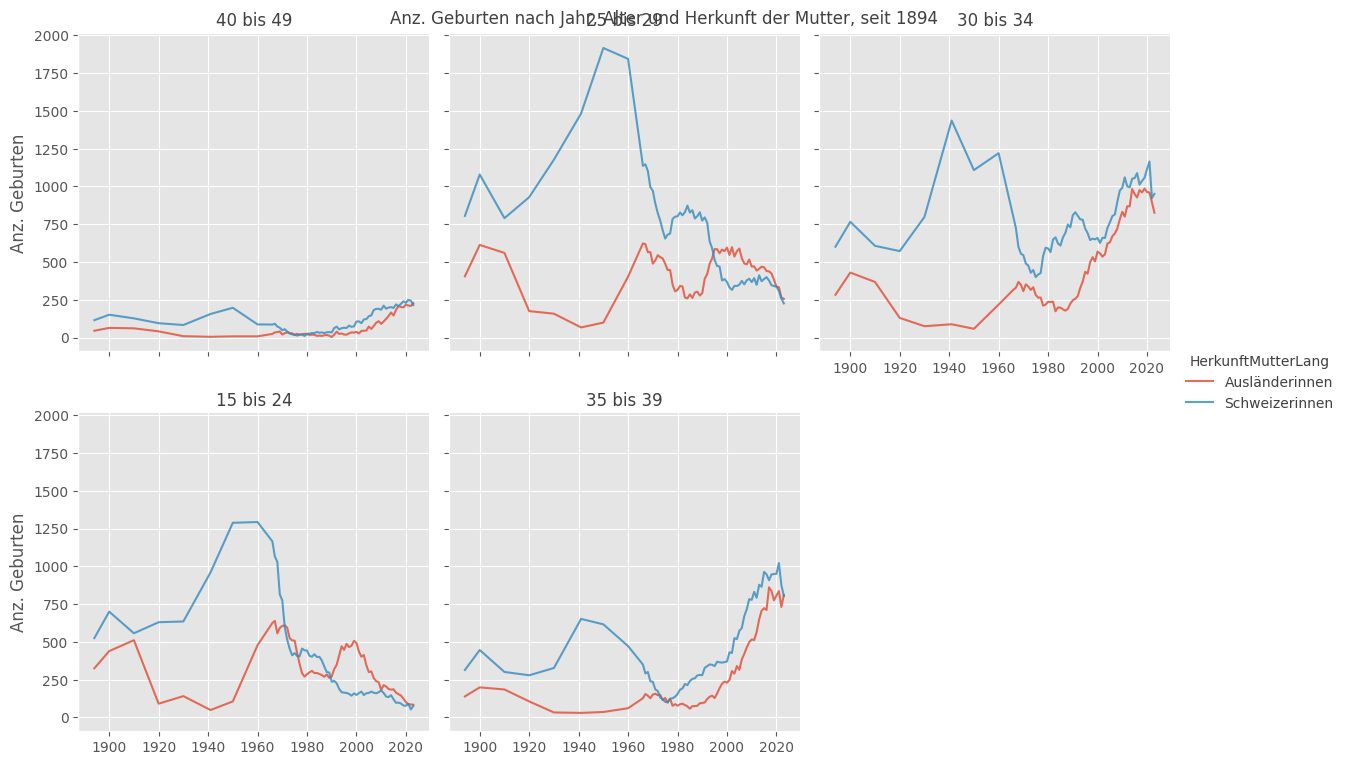

In [57]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested[data2betested['ThemaCd']==1].reset_index()
    ,col = "AlterVMutterKlasseLang"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzGebuWir"
    ,ylabel= "Anz. Geburten"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Anz. Geburten nach Jahr, Alter und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

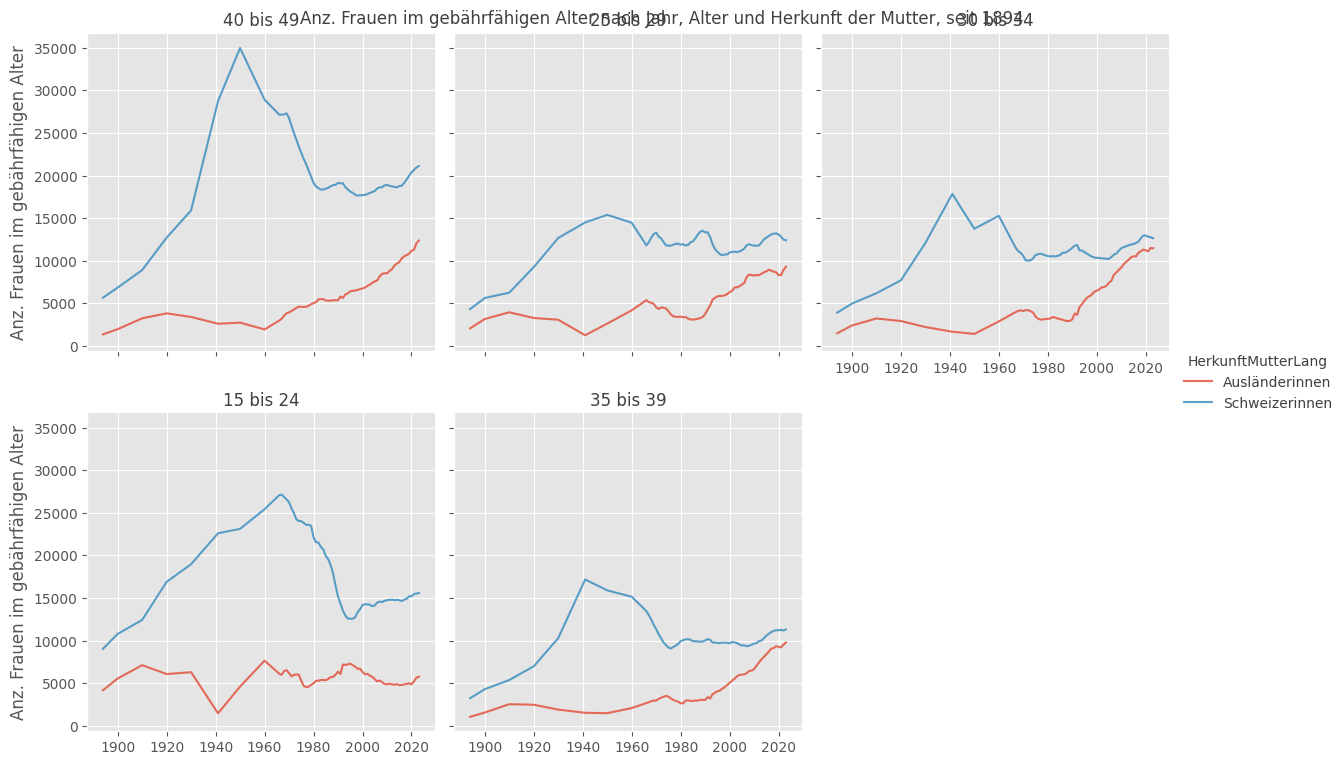

In [58]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested[data2betested['ThemaCd']==1].reset_index()
    ,col = "AlterVMutterKlasseLang"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "Frauen15bis49_noDM"
    ,ylabel= "Anz. Frauen im gebährfähigen Alter"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Anz. Frauen im gebährfähigen Alter nach Jahr, Alter und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [49]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [50]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['ZuzKtHistLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = div9ntr+qual12da+qual12br+qual12

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'St. Gallen': '#A30059', 'Zürich': '#DB247D', 'Schwyz': '#FF579E', 'Graubünden / Grigioni / Grischun': '#FFA8D0', 'Seit Geburt in Zürich': '#E4E0DF', 'Bern / Berne': '#A8DBB1', 'Valais / Wallis': '#55BC5D', 'Fribourg / Freiburg': '#1F9E31', 'Aargau': '#10652A', 'Thurgau': '#0017BF', 'Basel-Stadt': '#0072D7', 'Basel-Landschaft': '#00A5D2', 'Ticino': '#5E359A', 'Vaud': '#BA0062', 'Jura': '#DA5563', 'Zug': '#00615D', 'Uri': '#00770F', 'Luzern': '#7BA600', 'Solothurn': '#7B4100', 'Appenzell Ausserrhoden': '#DC5500', 'Obwalden': '#DA9C00', 'Neuchâtel': '#5D4BFE', 'Glarus': '#4AA9FF', 'Schaffhausen': '#55FFFF', 'Genève': '#986AD5', 'Nidwalden': '#FC4C99', 'Unbekannt': '#FF919A', 'Ausland': '#349894', 'Appenzell Innerrhoden': '#44B14A', 'Schweiz Unbekannt': '#B7E14E'}


##### Aufschlüssellung im aktuellsten Jahr

In [81]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[data2betested.index.max()].reset_index()
    ,levels=['ThemaLang','HerkunftMutterLang','AlterVMutterKlasseLang']
    ,values="Fertilitaetsrate_noDM"
    ,color="Fertilitaetsrate_noDM"
    #, color_continuous_scale='Blues'
    #,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Fertilitätsrate, "+str(data2betested.index.max())
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000015F42D07F50>, 'ThemaLang', 'HerkunftMutterLang', 'AlterVMutterKlasseLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1565&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7BCEAF2600%2D5498%2D413B%2D88AA%2DBEE20C2F4F2F%7D%23InplviewHashceaf2600%2D5498%2D413b%2D88aa%2Dbee20c2f4f2f%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------